In [1]:
using Pkg
Pkg.activate(".")

using Revise
using LinearAlgebra
using Base.Iterators
import DictionaryLearning.FoldyLax as FL
using Plots
using Base.Threads
using CUDA, Adapt, KernelAbstractions
using JLD2

include("../debug.jl")
include("./presets.jl")
;

  Activating project at `~/DictionaryLearning/examples/foldy-lax`


<!-- ## Settings & Setup -->

### Settings & Setup

In [ ]:
# backend
if CUDA.functional()
    back = CUDABackend()
    println("$INF using Cuda")
else
    back = CPU()
    println("$INF using CPU")
end

# preset = :med
preset = :tiny

f0, B, df, λ, r, ξ, τ, iwx, iwy, z = getpreset(preset)
;

[INF] using Cuda


In [3]:
nfs = B÷df
fs = f0 .+ df .* (-nfs÷2 : nfs÷2)
p = length(fs)
n = size(r, 2)
m = size(ξ, 2)
k = size(z, 2)

# wave numbers
wns = fs .* (2π / 3e8);

println("$INF central wavelength: $λ")
println("$INF # freqs: $(length(fs))")
println("$INF img. window size: $(length(iwx))×$(length(iwy))")

println("$INF # scatterers: $(size(ξ, 2))")
println("$INF # recievers: $(size(r, 2))")
println("$INF # sources: $(size(z, 2)*length(fs))")

println("$INF approx memory: $((
    16*(m*m*p + m*k*p + n*k*p + n*m*p + n*k*p + n*k*p) +
    8*max(m*m, m*k, n*k, n*m)
)*1e-9) GB")
;

[INF] central wavelength: 0.06
[INF] # freqs: 25
[INF] img. window size: 181×181
[INF] # scatterers: 1500
[INF] # recievers: 31
[INF] # sources: 819025
[INF] approx memory: 22.187041200000003 GB


### Form & factor incidence matrices

In [ ]:
function getGs()
    global r, ξ, τ, z, wns

    # preallocate arrays
    r = adapt(back, r)
    ξ = adapt(back, ξ)
    τ = adapt(back, τ)
    z = adapt(back, z)
    wns = adapt(back, collect(wns))
    Mξξ = adapt(back, Array{ComplexF64}(undef, m, m, p))
    Mξz = adapt(back, Array{ComplexF64}(undef, m, k, p))
    Mrz = adapt(back, Array{ComplexF64}(undef, n, k, p))
    Mrξ = adapt(back, Array{ComplexF64}(undef, n, m, p))
    Gscat = adapt(back, Array{ComplexF64}(undef, n, k, p))
    Ghom = adapt(back, Array{ComplexF64}(undef, n, k, p))

    nws = max(m*m, m*k, n*k, n*m)
    work = adapt(back, Vector{Float64}(undef, nws))

    println("$INF actual memory: $(
        (sizeof(r) + sizeof(ξ) + sizeof(τ) + sizeof(z) +
        sizeof(wns) + sizeof(Mξξ) + sizeof(Mξz) + sizeof(Mrz) + sizeof(Mrξ) + 
        sizeof(Gscat) + sizeof(Ghom) + sizeof(work))*1e-9
    ) GB")

    println("$STS solving for Mξξ")
    elap = @elapsed begin
        FL.compM!(Mξξ, ξ, wns, work, τ)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS solving for Mξz")
    elap = @elapsed begin
        FL.compM!(Mξz, ξ, z, wns, work)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS solving for Mrz")
    elap = @elapsed begin
        FL.compM!(Mrz, r, z, wns, work)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS solving for Mrξ")
    elap = @elapsed begin
        FL.compM!(Mrξ, r, ξ, wns, work, τ)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS factorizing Mξξ")
    elap = @elapsed begin
        Mξξfac = [lu!(view(Mξξ, :, :, s)) for s in 1:p]
    end
    println("$TAB$INF elapsed: $elap s")

    # green's function for scattered system
    println("$STS getting Green's tensor")
    elap = @elapsed begin
        FL.compG!(Gscat, Mξξfac, Mrξ, Mξz, Mrz, wns)
    end
    println("$TAB$INF elapsed: $elap s")

    # green's function for homogenous system
    Ghom = Mrz

    return Gscat, Ghom
end

Gscat, Ghom = getGs()
;

[INF] actual memory: 22.187876408 GB
[STS] solving for Mξξ
     [INF] elapsed: 0.000420816
[STS] solving for Mξz
     [INF] elapsed: 0.000694946
[STS] solving for Mrz
     [INF] elapsed: 4.766e-5
[STS] solving for Mrξ
     [INF] elapsed: 6.8911e-5
[STS] factorizing Mξξ
     [INF] elapsed: 0.654893792
[STS] getting Green's tensor
     [INF] elapsed: 13.491340508


In [5]:
@save "../../temp/fl.jld2" G=adapt(CPU(), Gscat)

### Plot results

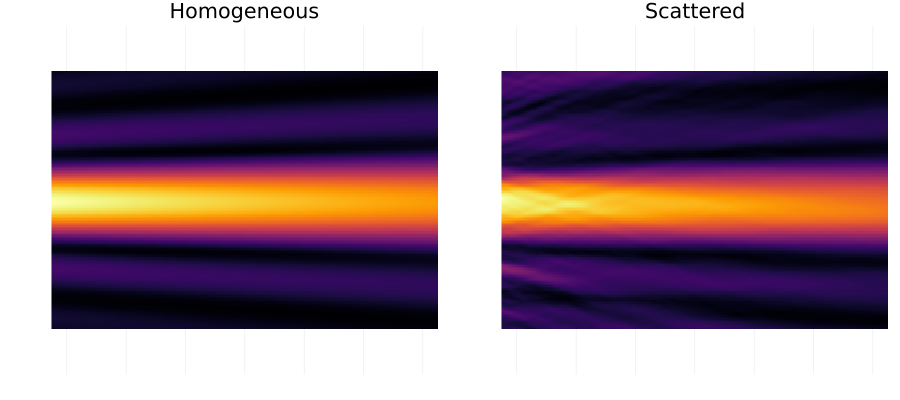

In [6]:
function plotkm()
    # data matrix
    ky, kx = length(iwy), length(iwx)
    X = zeros(ComplexF64, kx, ky, p)
    x = view(X, fld(kx,2), fld(ky,2), :)
    x .= randn(ComplexF64, p)
    x ./= norm(x)
    X = adapt(back, X)

    Yscat = reshape(Gscat, n, k*p) * reshape(X, k*p)
    Yhom = reshape(Ghom, n, k*p) * reshape(X, k*p)

    kmscat = reshape(adjoint(reshape(Gscat, n, k*p)) * Yscat, k, p)
    kmhom = reshape(adjoint(reshape(Ghom, n, k*p)) * Yhom, k, p)

    imgscat = adapt(CPU(), reshape(sum(abs.(kmscat), dims=2), ky, kx))
    imghom = adapt(CPU(), reshape(sum(abs.(kmhom), dims=2), ky, kx))

    p1 = heatmap(iwx, iwy, imghom, title="Homogeneous", aspect_ratio = :equal, legend = false, axis=false)
    p2 = heatmap(iwx, iwy, imgscat, title="Scattered", aspect_ratio = :equal, legend = false, axis=false)
    return plot(p1, p2, layout=(1,2), size=(900, 400))
end

plotkm()